**1 - Mount & Import**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os
import torch
import scipy.sparse
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import random
from matplotlib.patches import Patch
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score, recall_score,
                             roc_curve, auc, precision_recall_curve, average_precision_score)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from scipy.sparse import hstack, csr_matrix
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# ── Random Seed untuk IndoBERT ──────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {device}")
print(f"✅ Seed   : {SEED}")

Mounted at /content/drive
✅ Device : cuda
✅ Seed   : 42


**2 - Path & Load Data**

In [2]:
path_d1      = "/content/drive/MyDrive/SKRIPSI/CODE/DATA 1 (UMUM)"
path_d2      = "/content/drive/MyDrive/SKRIPSI/CODE/HASIL_SPLITTING"
path_lexicon = "/content/drive/MyDrive/SKRIPSI/CODE/LEXICON_V3"
save_path    = "/content/drive/MyDrive/SKRIPSI/CODE/HASIL MODELLING 12 SKEMA"
os.makedirs(save_path, exist_ok=True)

# ── Dataset 1 (teks) ─────────────────────────────────────────
df1_train = pd.read_csv(f"{path_d1}/data1_train.csv")
df1_val   = pd.read_csv(f"{path_d1}/data1_val.csv")
df1_test  = pd.read_csv(f"{path_d1}/data1_test.csv")

# ── Dataset 2 teks (untuk IndoBERT) ──────────────────────────
df2_train = pd.read_csv(f"{path_d2}/data_train.csv")
df2_val   = pd.read_csv(f"{path_d2}/data_val.csv")
df2_test  = pd.read_csv(f"{path_d2}/data_test.csv")

# ── Dataset 2 TF-IDF (untuk SVM D2) ──────────────────────────
X2_train = scipy.sparse.load_npz(f"{path_d2}/X_train_tfidf.npz")
X2_val   = scipy.sparse.load_npz(f"{path_d2}/X_val_tfidf.npz")
X2_test  = scipy.sparse.load_npz(f"{path_d2}/X_test_tfidf.npz")
y2_train = np.load(f"{path_d2}/y_train.npy")
y2_val   = np.load(f"{path_d2}/y_val.npy")
y2_test  = np.load(f"{path_d2}/y_test.npy")

# ── Lexicon ───────────────────────────────────────────────────
df_lexicon_svm      = pd.read_csv(f"{path_lexicon}/lexicon_svm.csv")
df_lexicon_indobert = pd.read_csv(f"{path_lexicon}/lexicon_indobert.csv")

print(f"✅ D1 Train: {len(df1_train)} | Val: {len(df1_val)} | Test: {len(df1_test)}")
print(f"✅ D2 Train (teks): {len(df2_train)} | Val: {len(df2_val)} | Test: {len(df2_test)}")
print(f"✅ D2 Train (TF-IDF): {X2_train.shape} | Val: {X2_val.shape} | Test: {X2_test.shape}")
print(f"✅ Lexicon SVM      : {len(df_lexicon_svm)} kata")
print(f"✅ Lexicon IndoBERT : {len(df_lexicon_indobert)} kata")

✅ D1 Train: 5430 | Val: 776 | Test: 1552
✅ D2 Train (teks): 1777 | Val: 254 | Test: 508
✅ D2 Train (TF-IDF): (1777, 5000) | Val: (254, 5000) | Test: (508, 5000)
✅ Lexicon SVM      : 2179 kata
✅ Lexicon IndoBERT : 2179 kata


**3 - Fungsi Lexicon**

In [3]:
def hitung_skor_lexicon(teks, lexicon_dict):
    kata_list = str(teks).split()
    skor = sum(lexicon_dict.get(kata, 0) for kata in kata_list)
    return skor

lexicon_svm_dict      = dict(zip(df_lexicon_svm['kata'],      df_lexicon_svm['skor_sarkasme']))
lexicon_indobert_dict = dict(zip(df_lexicon_indobert['kata'], df_lexicon_indobert['skor_sarkasme']))

print("✅ Fungsi & dictionary lexicon siap!")

✅ Fungsi & dictionary lexicon siap!


**4 - Fungsi Evaluasi**

In [4]:
def evaluasi_model(y_true, y_pred, nama_skema):
    print(f"\n{'='*55}")
    print(f"  HASIL EVALUASI: {nama_skema}")
    print(f"{'='*55}")

    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred, average='weighted'):.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=['Non-Sarkasme', 'Sarkasme'],
        digits=4
    ))

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Non-Sarkasme', 'Sarkasme'],
        yticklabels=['Non-Sarkasme', 'Sarkasme']
    )

    plt.title(f'Confusion Matrix - {nama_skema}', fontweight='bold')
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.tight_layout()

    plt.savefig(f"{save_path}/cm_{nama_skema.replace(' ', '_')}.png", dpi=300)
    plt.show()

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, average='weighted'),
        'precision': precision_score(y_true, y_pred, average='weighted'),
        'recall': recall_score(y_true, y_pred, average='weighted')
    }

print("✅ Fungsi evaluasi siap!")

✅ Fungsi evaluasi siap!


**5 - Fungsi SVM**

In [5]:
# ── Skema 2, 8 (SVM D1, SVM D1+Lexicon) → TANPA penanganan imbalance ──
def train_svm_teks(df_train, df_val, df_test, nama_skema, lexicon_dict=None):
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
    X_train = tfidf.fit_transform(df_train['text_clean'].fillna(''))
    X_val   = tfidf.transform(df_val['text_clean'].fillna(''))
    X_test  = tfidf.transform(df_test['text_clean'].fillna(''))

    if lexicon_dict:
        train_lex = df_train['text_clean'].apply(
            lambda x: hitung_skor_lexicon(x, lexicon_dict)).values.reshape(-1, 1)
        val_lex   = df_val['text_clean'].apply(
            lambda x: hitung_skor_lexicon(x, lexicon_dict)).values.reshape(-1, 1)
        test_lex  = df_test['text_clean'].apply(
            lambda x: hitung_skor_lexicon(x, lexicon_dict)).values.reshape(-1, 1)
        X_train = hstack([X_train, csr_matrix(train_lex)])
        X_val   = hstack([X_val,   csr_matrix(val_lex)])
        X_test  = hstack([X_test,  csr_matrix(test_lex)])

    y_train = df_train['label'].values
    y_test  = df_test['label'].values

    svm    = SVC(kernel='linear', probability=True, random_state=42)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    y_prob = svm.predict_proba(X_test)[:, 1]
    hasil  = evaluasi_model(y_test, y_pred, nama_skema)
    return y_test, y_pred, y_prob, hasil


# ── Skema 6, 12 (SVM D1+D2, SVM D1+D2+Lexicon) → CLASS WEIGHT ──
def train_svm_teks_balanced(df_train, df_val, df_test, nama_skema, lexicon_dict=None):
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
    X_train = tfidf.fit_transform(df_train['text_clean'].fillna(''))
    X_val   = tfidf.transform(df_val['text_clean'].fillna(''))
    X_test  = tfidf.transform(df_test['text_clean'].fillna(''))

    if lexicon_dict:
        train_lex = df_train['text_clean'].apply(
            lambda x: hitung_skor_lexicon(x, lexicon_dict)).values.reshape(-1, 1)
        val_lex   = df_val['text_clean'].apply(
            lambda x: hitung_skor_lexicon(x, lexicon_dict)).values.reshape(-1, 1)
        test_lex  = df_test['text_clean'].apply(
            lambda x: hitung_skor_lexicon(x, lexicon_dict)).values.reshape(-1, 1)
        X_train = hstack([X_train, csr_matrix(train_lex)])
        X_val   = hstack([X_val,   csr_matrix(val_lex)])
        X_test  = hstack([X_test,  csr_matrix(test_lex)])

    y_train = df_train['label'].values
    y_test  = df_test['label'].values

    svm    = SVC(kernel='linear', probability=True,
                 class_weight='balanced', random_state=42)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    y_prob = svm.predict_proba(X_test)[:, 1]
    hasil  = evaluasi_model(y_test, y_pred, nama_skema)
    return y_test, y_pred, y_prob, hasil


# ── Skema 4, 10 (SVM D2, SVM D2+Lexicon) → SMOTE ──
def train_svm_sparse_smote(X_train, y_train, X_test, y_test,
                            df_train_teks, df_test_teks,
                            nama_skema, lexicon_dict=None):
    X_tr = X_train.copy()
    X_te = X_test.copy()

    if lexicon_dict:
        n_train   = X_tr.shape[0]
        n_test    = X_te.shape[0]
        train_lex = np.array([
            hitung_skor_lexicon(t, lexicon_dict)
            for t in df_train_teks['text_clean'].fillna('').tolist()[:n_train]
        ]).reshape(-1, 1)
        test_lex  = np.array([
            hitung_skor_lexicon(t, lexicon_dict)
            for t in df_test_teks['text_clean'].fillna('').tolist()[:n_test]
        ]).reshape(-1, 1)
        X_tr = hstack([X_tr, csr_matrix(train_lex)])
        X_te = hstack([X_te, csr_matrix(test_lex)])

    # SMOTE hanya diterapkan ke data TRAIN
    smote = SMOTE(
        sampling_strategy=1.0,
        random_state=42,
        k_neighbors=5
    )

    X_tr_res, y_train_res = smote.fit_resample(csr_matrix(X_tr), y_train)
    print(f"   → Sebelum SMOTE: {np.bincount(y_train)} | Setelah SMOTE: {np.bincount(y_train_res)}")

    svm    = SVC(kernel='linear', probability=True, random_state=42)
    svm.fit(X_tr_res, y_train_res)
    y_pred = svm.predict(X_te)
    y_prob = svm.predict_proba(X_te)[:, 1]
    hasil  = evaluasi_model(y_test, y_pred, nama_skema)
    return y_test, y_pred, y_prob, hasil

print("✅ Fungsi SVM (tanpa / balanced / SMOTE) siap!")

✅ Fungsi SVM (tanpa / balanced / SMOTE) siap!


**6 - Tokenizer & Class Dataset**

In [6]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

class SarkasmeDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

class SarkasmeDatasetLexicon(Dataset):
    def __init__(self, texts, labels, tokenizer, lexicon_dict, max_len=128):
        self.texts        = texts
        self.labels       = labels
        self.tokenizer    = tokenizer
        self.lexicon_dict = lexicon_dict
        self.max_len      = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        skor = hitung_skor_lexicon(self.texts[idx], self.lexicon_dict)
        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'lexicon_score' : torch.tensor(skor, dtype=torch.float),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("✅ Tokenizer & Class Dataset siap!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenizer & Class Dataset siap!


**7 - Class & Fungsi IndoBERT**

In [7]:
class IndoBERTWithLexicon(torch.nn.Module):
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        self.bert       = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=num_labels)
        self.classifier = torch.nn.Linear(num_labels + 1, num_labels)

    def forward(self, input_ids, attention_mask, lexicon_score, labels=None, class_weights=None):
        outputs      = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        logits       = outputs.logits
        lexicon_score = lexicon_score.unsqueeze(1)
        combined     = torch.cat([logits, lexicon_score], dim=1)
        final_logits = self.classifier(combined)
        loss = None
        if labels is not None:
            loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fn(final_logits, labels)
        return loss, final_logits


# ── Skema 1, 7 (IndoBERT D1, IndoBERT D1+Lexicon) → TANPA class weight ──
def train_indobert(train_texts, train_labels, val_texts, val_labels,
                   epochs=3, batch_size=16, nama_skema="IndoBERT"):
    train_dataset = SarkasmeDataset(train_texts, train_labels, tokenizer)
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model     = AutoModelForSequenceClassification.from_pretrained(
        "indobenchmark/indobert-base-p1", num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=len(train_loader) * epochs
    )

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            outputs = model(
                input_ids      = batch['input_ids'].to(device),
                attention_mask = batch['attention_mask'].to(device),
                labels         = batch['label'].to(device)
            )
            outputs.loss.backward()
            total_loss += outputs.loss.item()
            optimizer.step()
            scheduler.step()
        print(f"  Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")

    model_path = f"{save_path}/{nama_skema.replace(' ', '_')}"
    os.makedirs(model_path, exist_ok=True)
    model.save_pretrained(model_path)
    tokenizer.save_pretrained(model_path)
    print(f"✅ Model {nama_skema} disimpan!")
    return model


# ── Skema 3, 5, 9, 11 (IndoBERT D2, D1+D2, D2+Lexicon, D1+D2+Lexicon) → CLASS WEIGHT ──
def train_indobert_weighted(train_texts, train_labels, val_texts, val_labels,
                            epochs=3, batch_size=16, nama_skema="IndoBERT_Weighted"):
    class_weights_np = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels),
        y=train_labels
    )
    class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
    print(f"   → Class weights: {class_weights_np}")

    train_dataset = SarkasmeDataset(train_texts, train_labels, tokenizer)
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model     = AutoModelForSequenceClassification.from_pretrained(
        "indobenchmark/indobert-base-p1", num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=len(train_loader) * epochs
    )
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            outputs = model(
                input_ids      = batch['input_ids'].to(device),
                attention_mask = batch['attention_mask'].to(device)
            )
            loss = loss_fn(outputs.logits, batch['label'].to(device))
            loss.backward()
            total_loss += loss.item()
            optimizer.step()
            scheduler.step()
        print(f"  Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")

    model_path = f"{save_path}/{nama_skema.replace(' ', '_')}"
    os.makedirs(model_path, exist_ok=True)
    model.save_pretrained(model_path)
    tokenizer.save_pretrained(model_path)
    print(f"✅ Model {nama_skema} disimpan!")
    return model


def evaluasi_indobert(model, test_texts, test_labels, nama_skema):
    test_dataset = SarkasmeDataset(test_texts, test_labels, tokenizer)
    test_loader  = DataLoader(test_dataset, batch_size=16)
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            outputs = model(
                input_ids      = batch['input_ids'].to(device),
                attention_mask = batch['attention_mask'].to(device)
            )
            probs = torch.softmax(outputs.logits, dim=1)[:, 1]
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['label'].numpy())
            all_probs.extend(probs.cpu().numpy())
    hasil = evaluasi_model(all_labels, all_preds, nama_skema)
    return all_labels, all_preds, all_probs, hasil


# ── Skema 7 (IndoBERT D1+Lexicon) → TANPA class weight ──
def train_indobert_lexicon(train_texts, train_labels, val_texts, val_labels,
                           lexicon_dict, epochs=3, batch_size=16,
                           nama_skema="IndoBERT+Lexicon"):
    train_dataset = SarkasmeDatasetLexicon(
        train_texts, train_labels, tokenizer, lexicon_dict)
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model     = IndoBERTWithLexicon("indobenchmark/indobert-base-p1").to(device)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=len(train_loader) * epochs
    )

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            loss, _ = model(
                input_ids      = batch['input_ids'].to(device),
                attention_mask = batch['attention_mask'].to(device),
                lexicon_score  = batch['lexicon_score'].to(device),
                labels         = batch['label'].to(device)
            )
            loss.backward()
            total_loss += loss.item()
            optimizer.step()
            scheduler.step()
        print(f"  Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")

    model_path = f"{save_path}/{nama_skema.replace(' ', '_')}"
    os.makedirs(model_path, exist_ok=True)
    torch.save(model.state_dict(), f"{model_path}/model.pt")
    tokenizer.save_pretrained(model_path)
    print(f"✅ Model {nama_skema} disimpan!")
    return model


# ── Skema 9, 11 (IndoBERT D2+Lexicon, D1+D2+Lexicon) → CLASS WEIGHT ──
def train_indobert_lexicon_weighted(train_texts, train_labels, val_texts, val_labels,
                                    lexicon_dict, epochs=3, batch_size=16,
                                    nama_skema="IndoBERT+Lexicon_Weighted"):
    class_weights_np = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels),
        y=train_labels
    )
    class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
    print(f"   → Class weights: {class_weights_np}")

    train_dataset = SarkasmeDatasetLexicon(
        train_texts, train_labels, tokenizer, lexicon_dict)
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model     = IndoBERTWithLexicon("indobenchmark/indobert-base-p1").to(device)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=len(train_loader) * epochs
    )

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            loss, _ = model(
                input_ids      = batch['input_ids'].to(device),
                attention_mask = batch['attention_mask'].to(device),
                lexicon_score  = batch['lexicon_score'].to(device),
                labels         = batch['label'].to(device),
                class_weights  = class_weights
            )
            loss.backward()
            total_loss += loss.item()
            optimizer.step()
            scheduler.step()
        print(f"  Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")

    model_path = f"{save_path}/{nama_skema.replace(' ', '_')}"
    os.makedirs(model_path, exist_ok=True)
    torch.save(model.state_dict(), f"{model_path}/model.pt")
    tokenizer.save_pretrained(model_path)
    print(f"✅ Model {nama_skema} disimpan!")
    return model


def evaluasi_indobert_lexicon(model, test_texts, test_labels,
                               lexicon_dict, nama_skema):
    test_dataset = SarkasmeDatasetLexicon(
        test_texts, test_labels, tokenizer, lexicon_dict)
    test_loader  = DataLoader(test_dataset, batch_size=16)
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            _, logits = model(
                input_ids      = batch['input_ids'].to(device),
                attention_mask = batch['attention_mask'].to(device),
                lexicon_score  = batch['lexicon_score'].to(device)
            )
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['label'].numpy())
            all_probs.extend(probs.cpu().numpy())
    hasil = evaluasi_model(all_labels, all_preds, nama_skema)
    return all_labels, all_preds, all_probs, hasil

print("✅ Semua fungsi IndoBERT (tanpa / class weight) siap!")

✅ Semua fungsi IndoBERT (tanpa / class weight) siap!


**8 - Persiapan Data & Recovery System**

In [8]:
df_train_d1d2 = pd.concat([df1_train, df2_train], ignore_index=True)
df_val_d1d2   = pd.concat([df1_val,   df2_val],   ignore_index=True)
df_test_d1d2  = pd.concat([df1_test,  df2_test],  ignore_index=True)

print(f"✅ D1+D2 Train: {len(df_train_d1d2)} | Val: {len(df_val_d1d2)} | Test: {len(df_test_d1d2)}")

if os.path.exists(f"{save_path}/hasil_sementara.csv"):
    df_existing = pd.read_csv(f"{save_path}/hasil_sementara.csv")
    all_results = df_existing.set_index('Skema').to_dict('index')
    print(f"\n✅ Ditemukan {len(all_results)} hasil skema sebelumnya:")
    for skema in all_results:
        print(f"   ✅ {skema} → sudah selesai, skip!")
else:
    all_results = {}
    print("\n⚠️ Tidak ada hasil sebelumnya, mulai dari awal")

# ===== Recovery prediction =====
pred_path = f"{save_path}/all_preds.pkl"

if os.path.exists(pred_path):
    with open(pred_path, "rb") as f:
        all_preds_dict = pickle.load(f)
    print(f"✅ Prediction {len(all_preds_dict)} skema berhasil dipulihkan")
else:
    all_preds_dict = {}
    print("⚠️ Belum ada prediction yang disimpan")

def simpan_sementara():
    df_tmp = pd.DataFrame([
        {'Skema': skema, **v}
        for skema, v in all_results.items()
    ])
    df_tmp.to_csv(f"{save_path}/hasil_sementara.csv", index=False)

    # simpan seluruh prediction
    with open(f"{save_path}/all_preds.pkl", "wb") as f:
        pickle.dump(all_preds_dict, f)

    print(f"💾 Hasil sementara disimpan ({len(all_results)} skema selesai)")

✅ D1+D2 Train: 7207 | Val: 1030 | Test: 2060

✅ Ditemukan 12 hasil skema sebelumnya:
   ✅ Skema 1 IndoBERT D1 - Tanpa Lexicon → sudah selesai, skip!
   ✅ Skema 2 SVM D1 - Tanpa Lexicon → sudah selesai, skip!
   ✅ Skema 3 IndoBERT D2 - Tanpa Lexicon → sudah selesai, skip!
   ✅ Skema 4 SVM D2 - Tanpa Lexicon → sudah selesai, skip!
   ✅ Skema 5 IndoBERT D1+D2 - Tanpa Lexicon → sudah selesai, skip!
   ✅ Skema 6 SVM D1+D2 - Tanpa Lexicon → sudah selesai, skip!
   ✅ Skema 7 IndoBERT D1+Lexicon → sudah selesai, skip!
   ✅ Skema 8 SVM D1+Lexicon → sudah selesai, skip!
   ✅ Skema 9 IndoBERT D2+Lexicon → sudah selesai, skip!
   ✅ Skema 10 SVM D2+Lexicon → sudah selesai, skip!
   ✅ Skema 11 IndoBERT D1+D2+Lexicon → sudah selesai, skip!
   ✅ Skema 12 SVM D1+D2+Lexicon → sudah selesai, skip!
✅ Prediction 12 skema berhasil dipulihkan


**9 - Skema 1: IndoBERT D1 (Tanpa Lexicon)**

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


🚀 Skema 1 IndoBERT D1 - Tanpa Lexicon


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 - Loss: 0.2950
  Epoch 2/3 - Loss: 0.0903
  Epoch 3/3 - Loss: 0.0335


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model Skema 1 IndoBERT D1 - Tanpa Lexicon disimpan!

  HASIL EVALUASI: Skema 1 IndoBERT D1 - Tanpa Lexicon
Accuracy  : 0.9543
F1-Score  : 0.9542
Precision : 0.9544
Recall    : 0.9543

Classification Report:
              precision    recall  f1-score   support

Non-Sarkasme     0.9481    0.9711    0.9595       865
    Sarkasme     0.9625    0.9330    0.9475       687

    accuracy                         0.9543      1552
   macro avg     0.9553    0.9521    0.9535      1552
weighted avg     0.9544    0.9543    0.9542      1552



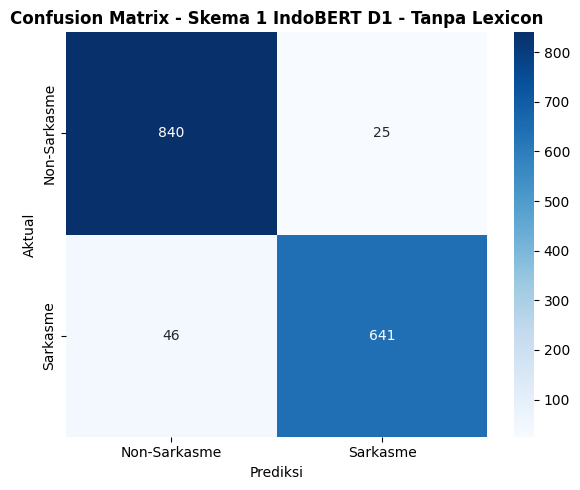

💾 Hasil sementara disimpan (1 skema selesai)


In [ ]:
nama = 'Skema 1 IndoBERT D1 - Tanpa Lexicon'
if nama in all_results:
    print(f"⏭️ {nama} sudah selesai, skip!")
else:
    print(f"🚀 {nama}")
    model_path = f"{save_path}/{nama.replace(' ', '_')}"
    if os.path.exists(model_path):
        print("   → Load model yang sudah ada...")
        model_s1 = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)
    else:
        model_s1 = train_indobert(
            df1_train['text_clean'].tolist(), df1_train['label'].tolist(),
            df1_val['text_clean'].tolist(),   df1_val['label'].tolist(),
            nama_skema=nama
        )
    y_true_s1, y_pred_s1, y_prob_s1, hasil_s1 = evaluasi_indobert(
        model_s1, df1_test['text_clean'].tolist(),
        df1_test['label'].tolist(), nama
    )
    all_results[nama]    = hasil_s1
    all_preds_dict[nama] = (y_true_s1, y_pred_s1, y_prob_s1)
    simpan_sementara()
    del model_s1; torch.cuda.empty_cache()

**10 - Skema 2: SVM D1 (Tanpa Lexicon)**

🚀 Skema 2 SVM D1 - Tanpa Lexicon

  HASIL EVALUASI: Skema 2 SVM D1 - Tanpa Lexicon
Accuracy  : 0.9491
F1-Score  : 0.9488
Precision : 0.9519
Recall    : 0.9491

Classification Report:
              precision    recall  f1-score   support

Non-Sarkasme     0.9226    0.9919    0.9560       865
    Sarkasme     0.9887    0.8952    0.9396       687

    accuracy                         0.9491      1552
   macro avg     0.9557    0.9436    0.9478      1552
weighted avg     0.9519    0.9491    0.9488      1552



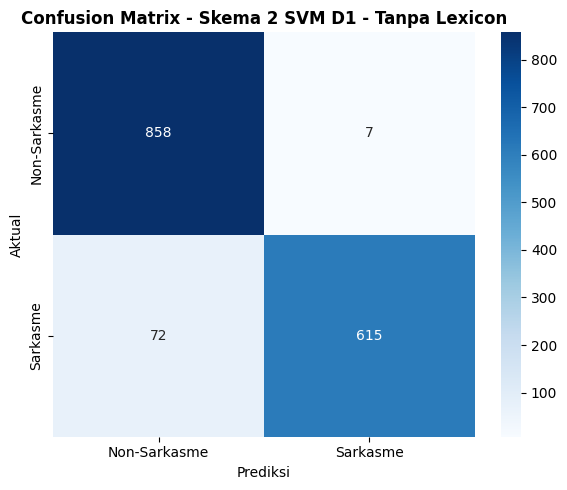

💾 Hasil sementara disimpan (2 skema selesai)


In [ ]:
nama = 'Skema 2 SVM D1 - Tanpa Lexicon'
if nama in all_results:
    print(f"⏭️ {nama} sudah selesai, skip!")
else:
    print(f"🚀 {nama}")
    y_true_s2, y_pred_s2, y_prob_s2, hasil_s2 = train_svm_teks(
        df1_train, df1_val, df1_test, nama_skema=nama
    )
    all_results[nama]    = hasil_s2
    all_preds_dict[nama] = (y_true_s2, y_pred_s2, y_prob_s2)
    simpan_sementara()

**11 - Skema 3: IndoBERT D2 (Tanpa Lexicon)**

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


🚀 Skema 3 IndoBERT D2 - Tanpa Lexicon
   → Class weights: [0.58685601 3.378327  ]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 - Loss: 0.4060
  Epoch 2/3 - Loss: 0.2051
  Epoch 3/3 - Loss: 0.1062


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model Skema 3 IndoBERT D2 - Tanpa Lexicon disimpan!

  HASIL EVALUASI: Skema 3 IndoBERT D2 - Tanpa Lexicon
Accuracy  : 0.8917
F1-Score  : 0.8947
Precision : 0.8989
Recall    : 0.8917

Classification Report:
              precision    recall  f1-score   support

Non-Sarkasme     0.9479    0.9238    0.9357       433
    Sarkasme     0.6163    0.7067    0.6584        75

    accuracy                         0.8917       508
   macro avg     0.7821    0.8152    0.7970       508
weighted avg     0.8989    0.8917    0.8947       508



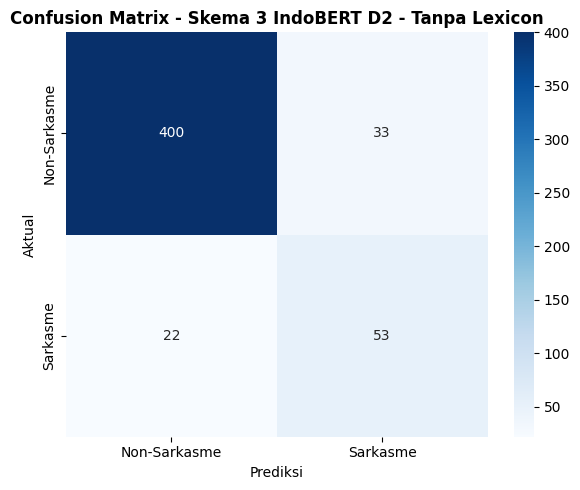

💾 Hasil sementara disimpan (3 skema selesai)


In [ ]:
nama = 'Skema 3 IndoBERT D2 - Tanpa Lexicon'
if nama in all_results:
    print(f"⏭️ {nama} sudah selesai, skip!")
else:
    print(f"🚀 {nama}")
    model_path = f"{save_path}/{nama.replace(' ', '_')}"
    if os.path.exists(model_path):
        print("   → Load model yang sudah ada...")
        model_s3 = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)
    else:
        model_s3 = train_indobert_weighted(
            df2_train['text_clean'].tolist(), df2_train['label'].tolist(),
            df2_val['text_clean'].tolist(),   df2_val['label'].tolist(),
            nama_skema=nama
        )
    y_true_s3, y_pred_s3, y_prob_s3, hasil_s3 = evaluasi_indobert(
        model_s3, df2_test['text_clean'].tolist(),
        df2_test['label'].tolist(), nama
    )
    all_results[nama]    = hasil_s3
    all_preds_dict[nama] = (y_true_s3, y_pred_s3, y_prob_s3)
    simpan_sementara()
    del model_s3; torch.cuda.empty_cache()

**12 - Skema 4: SVM D2 (Tanpa Lexicon)**

In [10]:
nama = 'Skema 4 SVM D2 - Tanpa Lexicon'
if nama in all_results:
    print(f"⏭️ {nama} sudah selesai, skip!")
else:
    print(f"🚀 {nama}")
    y_true_s4, y_pred_s4, y_prob_s4, hasil_s4 = train_svm_sparse_smote(
        X2_train, y2_train, X2_test, y2_test,
        df2_train, df2_test, nama_skema=nama
    )
    all_results[nama]    = hasil_s4
    all_preds_dict[nama] = (y_true_s4, y_pred_s4, y_prob_s4)
    simpan_sementara()

⏭️ Skema 4 SVM D2 - Tanpa Lexicon sudah selesai, skip!


**13 - Skema 5: IndoBERT D1+D2 (Tanpa Lexicon)**

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


🚀 Skema 5 IndoBERT D1+D2 - Tanpa Lexicon
   → Class weights: [0.79372247 1.35114361]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 - Loss: 0.3186
  Epoch 2/3 - Loss: 0.1058
  Epoch 3/3 - Loss: 0.0334


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model Skema 5 IndoBERT D1+D2 - Tanpa Lexicon disimpan!

  HASIL EVALUASI: Skema 5 IndoBERT D1+D2 - Tanpa Lexicon
Accuracy  : 0.9325
F1-Score  : 0.9325
Precision : 0.9324
Recall    : 0.9325

Classification Report:
              precision    recall  f1-score   support

Non-Sarkasme     0.9447    0.9484    0.9466      1298
    Sarkasme     0.9115    0.9055    0.9085       762

    accuracy                         0.9325      2060
   macro avg     0.9281    0.9269    0.9275      2060
weighted avg     0.9324    0.9325    0.9325      2060



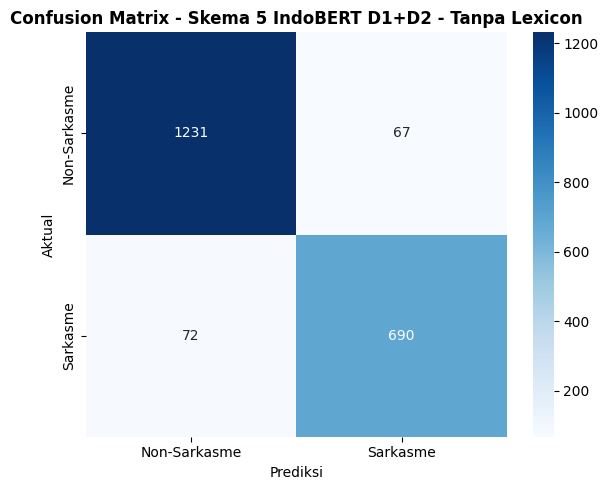

💾 Hasil sementara disimpan (5 skema selesai)


In [ ]:
nama = 'Skema 5 IndoBERT D1+D2 - Tanpa Lexicon'
if nama in all_results:
    print(f"⏭️ {nama} sudah selesai, skip!")
else:
    print(f"🚀 {nama}")
    model_path = f"{save_path}/{nama.replace(' ', '_')}"
    if os.path.exists(model_path):
        print("   → Load model yang sudah ada...")
        model_s5 = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)
    else:
        model_s5 = train_indobert_weighted(
            df_train_d1d2['text_clean'].tolist(), df_train_d1d2['label'].tolist(),
            df_val_d1d2['text_clean'].tolist(),   df_val_d1d2['label'].tolist(),
            nama_skema=nama
        )
    y_true_s5, y_pred_s5, y_prob_s5, hasil_s5 = evaluasi_indobert(
        model_s5, df_test_d1d2['text_clean'].tolist(),
        df_test_d1d2['label'].tolist(), nama
    )
    all_results[nama]    = hasil_s5
    all_preds_dict[nama] = (y_true_s5, y_pred_s5, y_prob_s5)
    simpan_sementara()
    del model_s5; torch.cuda.empty_cache()

**14 - Skema 6: SVM D1+D2 - Tanpa Lexicon**

🚀 Skema 6 SVM D1+D2 - Tanpa Lexicon

  HASIL EVALUASI: Skema 6 SVM D1+D2 - Tanpa Lexicon
Accuracy  : 0.9286
F1-Score  : 0.9279
Precision : 0.9292
Recall    : 0.9286

Classification Report:
              precision    recall  f1-score   support

Non-Sarkasme     0.9229    0.9676    0.9447      1298
    Sarkasme     0.9399    0.8622    0.8994       762

    accuracy                         0.9286      2060
   macro avg     0.9314    0.9149    0.9221      2060
weighted avg     0.9292    0.9286    0.9279      2060



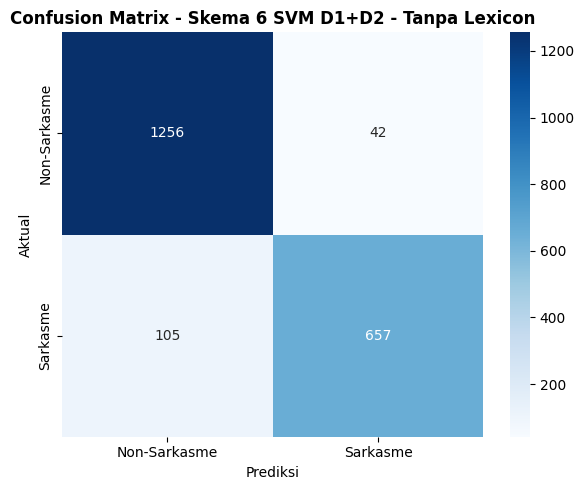

💾 Hasil sementara disimpan (6 skema selesai)


In [ ]:
nama = 'Skema 6 SVM D1+D2 - Tanpa Lexicon'
if nama in all_results:
    print(f"⏭️ {nama} sudah selesai, skip!")
else:
    print(f"🚀 {nama}")
    y_true_s6, y_pred_s6, y_prob_s6, hasil_s6 = train_svm_teks_balanced(
        df_train_d1d2, df_val_d1d2, df_test_d1d2, nama_skema=nama
    )
    all_results[nama]    = hasil_s6
    all_preds_dict[nama] = (y_true_s6, y_pred_s6, y_prob_s6)
    simpan_sementara()

**15 - Skema 7: IndoBERT D1+Lexicon**

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


🚀 Skema 7 IndoBERT D1+Lexicon


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 - Loss: 0.3736
  Epoch 2/3 - Loss: 0.1049
  Epoch 3/3 - Loss: 0.0381
✅ Model Skema 7 IndoBERT D1+Lexicon disimpan!

  HASIL EVALUASI: Skema 7 IndoBERT D1+Lexicon
Accuracy  : 0.9536
F1-Score  : 0.9535
Precision : 0.9539
Recall    : 0.9536

Classification Report:
              precision    recall  f1-score   support

Non-Sarkasme     0.9460    0.9723    0.9590       865
    Sarkasme     0.9638    0.9301    0.9467       687

    accuracy                         0.9536      1552
   macro avg     0.9549    0.9512    0.9528      1552
weighted avg     0.9539    0.9536    0.9535      1552



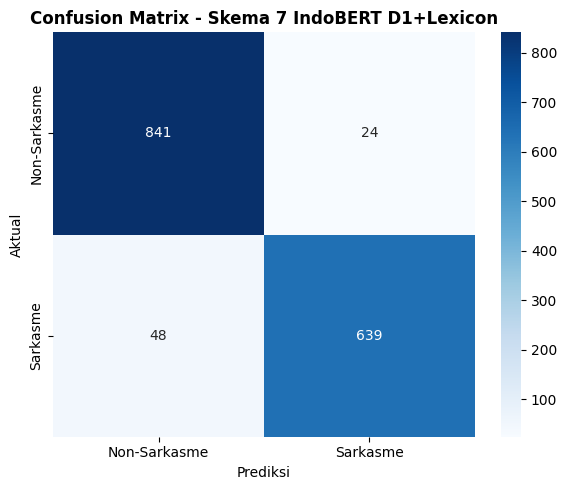

💾 Hasil sementara disimpan (7 skema selesai)


In [ ]:
nama = 'Skema 7 IndoBERT D1+Lexicon'
if nama in all_results:
    print(f"⏭️ {nama} sudah selesai, skip!")
else:
    print(f"🚀 {nama}")
    model_path = f"{save_path}/{nama.replace(' ', '_')}"
    if os.path.exists(model_path):
        print("   → Load model yang sudah ada...")
        model_s7 = IndoBERTWithLexicon("indobenchmark/indobert-base-p1").to(device)
        model_s7.load_state_dict(torch.load(f"{model_path}/model.pt"))
    else:
        model_s7 = train_indobert_lexicon(
            df1_train['text_clean'].tolist(), df1_train['label'].tolist(),
            df1_val['text_clean'].tolist(),   df1_val['label'].tolist(),
            lexicon_indobert_dict, nama_skema=nama
        )
    y_true_s7, y_pred_s7, y_prob_s7, hasil_s7 = evaluasi_indobert_lexicon(
        model_s7, df1_test['text_clean'].tolist(),
        df1_test['label'].tolist(), lexicon_indobert_dict, nama
    )
    all_results[nama]    = hasil_s7
    all_preds_dict[nama] = (y_true_s7, y_pred_s7, y_prob_s7)
    simpan_sementara()
    del model_s7; torch.cuda.empty_cache()

**16 - Skema 8: SVM D1+Lexicon**

🚀 Skema 8 SVM D1+Lexicon

  HASIL EVALUASI: Skema 8 SVM D1+Lexicon
Accuracy  : 0.9510
F1-Score  : 0.9507
Precision : 0.9537
Recall    : 0.9510

Classification Report:
              precision    recall  f1-score   support

Non-Sarkasme     0.9247    0.9931    0.9576       865
    Sarkasme     0.9904    0.8981    0.9420       687

    accuracy                         0.9510      1552
   macro avg     0.9575    0.9456    0.9498      1552
weighted avg     0.9537    0.9510    0.9507      1552



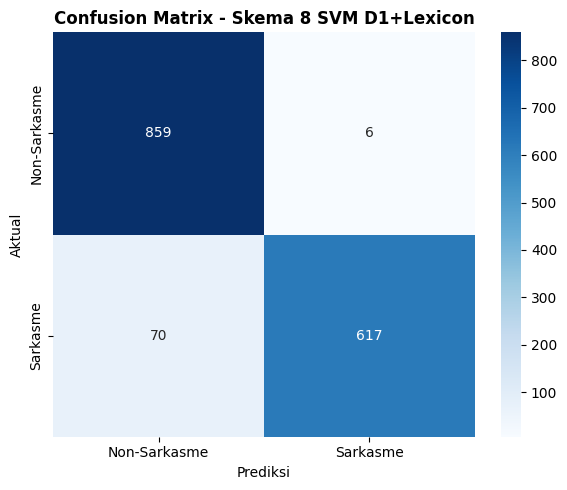

💾 Hasil sementara disimpan (8 skema selesai)


In [ ]:
nama = 'Skema 8 SVM D1+Lexicon'
if nama in all_results:
    print(f"⏭️ {nama} sudah selesai, skip!")
else:
    print(f"🚀 {nama}")
    y_true_s8, y_pred_s8, y_prob_s8, hasil_s8 = train_svm_teks(
        df1_train, df1_val, df1_test,
        nama_skema=nama, lexicon_dict=lexicon_svm_dict
    )
    all_results[nama]    = hasil_s8
    all_preds_dict[nama] = (y_true_s8, y_pred_s8, y_prob_s8)
    simpan_sementara()

**17 - Skema 9: IndoBERT D2+Lexicon**

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


🚀 Skema 9 IndoBERT D2+Lexicon
   → Class weights: [0.58685601 3.378327  ]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 - Loss: 2.6900
  Epoch 2/3 - Loss: 1.9089
  Epoch 3/3 - Loss: 1.7220
✅ Model Skema 9 IndoBERT D2+Lexicon disimpan!

  HASIL EVALUASI: Skema 9 IndoBERT D2+Lexicon
Accuracy  : 0.8406
F1-Score  : 0.8319
Precision : 0.8257
Recall    : 0.8406

Classification Report:
              precision    recall  f1-score   support

Non-Sarkasme     0.8911    0.9261    0.9083       433
    Sarkasme     0.4483    0.3467    0.3910        75

    accuracy                         0.8406       508
   macro avg     0.6697    0.6364    0.6496       508
weighted avg     0.8257    0.8406    0.8319       508



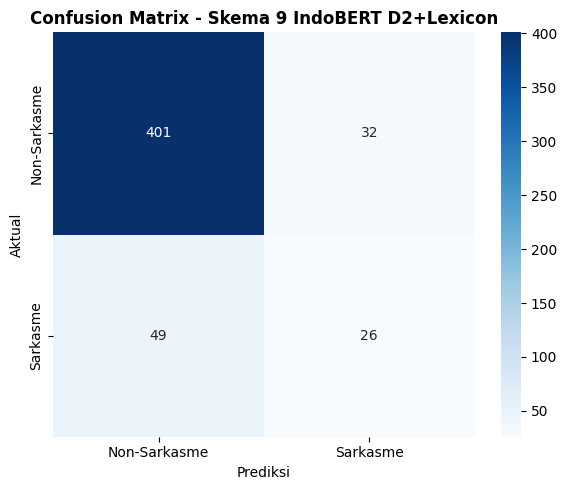

💾 Hasil sementara disimpan (9 skema selesai)


In [ ]:
nama = 'Skema 9 IndoBERT D2+Lexicon'
if nama in all_results:
    print(f"⏭️ {nama} sudah selesai, skip!")
else:
    print(f"🚀 {nama}")
    model_path = f"{save_path}/{nama.replace(' ', '_')}"
    if os.path.exists(model_path):
        print("   → Load model yang sudah ada...")
        model_s9 = IndoBERTWithLexicon("indobenchmark/indobert-base-p1").to(device)
        model_s9.load_state_dict(torch.load(f"{model_path}/model.pt"))
    else:
        model_s9 = train_indobert_lexicon_weighted(
            df2_train['text_clean'].tolist(), df2_train['label'].tolist(),
            df2_val['text_clean'].tolist(),   df2_val['label'].tolist(),
            lexicon_indobert_dict, nama_skema=nama
        )
    y_true_s9, y_pred_s9, y_prob_s9, hasil_s9 = evaluasi_indobert_lexicon(
        model_s9, df2_test['text_clean'].tolist(),
        df2_test['label'].tolist(), lexicon_indobert_dict, nama
    )
    all_results[nama]    = hasil_s9
    all_preds_dict[nama] = (y_true_s9, y_pred_s9, y_prob_s9)
    simpan_sementara()
    del model_s9; torch.cuda.empty_cache()

**18 - Skema 10: SVM D2+Lexicon**

🚀 Skema 10 SVM D2+Lexicon
   → Sebelum SMOTE: [1514  263] | Setelah SMOTE: [1514 1514]

  HASIL EVALUASI: Skema 10 SVM D2+Lexicon
Accuracy  : 0.8898
F1-Score  : 0.8834
Precision : 0.8809
Recall    : 0.8898

Classification Report:
              precision    recall  f1-score   support

Non-Sarkasme     0.9180    0.9561    0.9367       433
    Sarkasme     0.6667    0.5067    0.5758        75

    accuracy                         0.8898       508
   macro avg     0.7923    0.7314    0.7562       508
weighted avg     0.8809    0.8898    0.8834       508



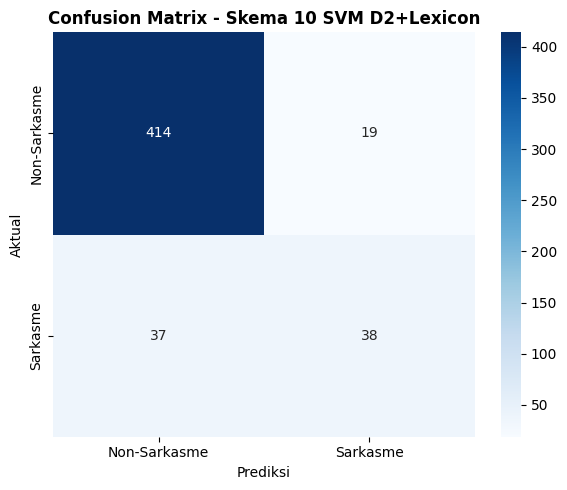

💾 Hasil sementara disimpan (10 skema selesai)


In [ ]:
nama = 'Skema 10 SVM D2+Lexicon'
if nama in all_results:
    print(f"⏭️ {nama} sudah selesai, skip!")
else:
    print(f"🚀 {nama}")
    y_true_s10, y_pred_s10, y_prob_s10, hasil_s10 = train_svm_sparse_smote(
        X2_train, y2_train, X2_test, y2_test,
        df2_train, df2_test,
        nama_skema=nama, lexicon_dict=lexicon_svm_dict
    )
    all_results[nama]    = hasil_s10
    all_preds_dict[nama] = (y_true_s10, y_pred_s10, y_prob_s10)
    simpan_sementara()

**19 - Skema 11: IndoBERT D1+D2+Lexicon**

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


🚀 Skema 11 IndoBERT D1+D2+Lexicon
   → Class weights: [0.79372247 1.35114361]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 - Loss: 0.3537
  Epoch 2/3 - Loss: 0.1510
  Epoch 3/3 - Loss: 0.0651
✅ Model Skema 11 IndoBERT D1+D2+Lexicon disimpan!

  HASIL EVALUASI: Skema 11 IndoBERT D1+D2+Lexicon
Accuracy  : 0.9301
F1-Score  : 0.9300
Precision : 0.9300
Recall    : 0.9301

Classification Report:
              precision    recall  f1-score   support

Non-Sarkasme     0.9418    0.9476    0.9447      1298
    Sarkasme     0.9098    0.9003    0.9050       762

    accuracy                         0.9301      2060
   macro avg     0.9258    0.9239    0.9249      2060
weighted avg     0.9300    0.9301    0.9300      2060



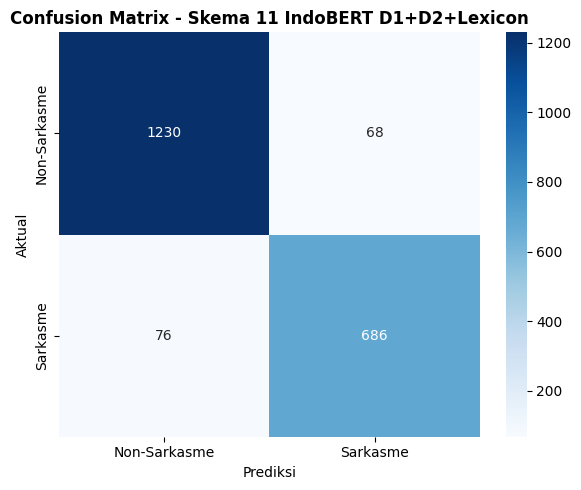

💾 Hasil sementara disimpan (11 skema selesai)


In [ ]:
nama = 'Skema 11 IndoBERT D1+D2+Lexicon'
if nama in all_results:
    print(f"⏭️ {nama} sudah selesai, skip!")
else:
    print(f"🚀 {nama}")
    model_path = f"{save_path}/{nama.replace(' ', '_')}"
    if os.path.exists(model_path):
        print("   → Load model yang sudah ada...")
        model_s11 = IndoBERTWithLexicon("indobenchmark/indobert-base-p1").to(device)
        model_s11.load_state_dict(torch.load(f"{model_path}/model.pt"))
    else:
        model_s11 = train_indobert_lexicon_weighted(
            df_train_d1d2['text_clean'].tolist(), df_train_d1d2['label'].tolist(),
            df_val_d1d2['text_clean'].tolist(),   df_val_d1d2['label'].tolist(),
            lexicon_indobert_dict, nama_skema=nama
        )
    y_true_s11, y_pred_s11, y_prob_s11, hasil_s11 = evaluasi_indobert_lexicon(
        model_s11, df_test_d1d2['text_clean'].tolist(),
        df_test_d1d2['label'].tolist(), lexicon_indobert_dict, nama
    )
    all_results[nama]    = hasil_s11
    all_preds_dict[nama] = (y_true_s11, y_pred_s11, y_prob_s11)
    simpan_sementara()
    del model_s11; torch.cuda.empty_cache()

**20 - Skema 12: SVM D1+D2+Lexicon**

🚀 Skema 12 SVM D1+D2+Lexicon

  HASIL EVALUASI: Skema 12 SVM D1+D2+Lexicon
Accuracy  : 0.9301
F1-Score  : 0.9292
Precision : 0.9315
Recall    : 0.9301

Classification Report:
              precision    recall  f1-score   support

Non-Sarkasme     0.9181    0.9761    0.9462      1298
    Sarkasme     0.9544    0.8517    0.9001       762

    accuracy                         0.9301      2060
   macro avg     0.9363    0.9139    0.9232      2060
weighted avg     0.9315    0.9301    0.9292      2060



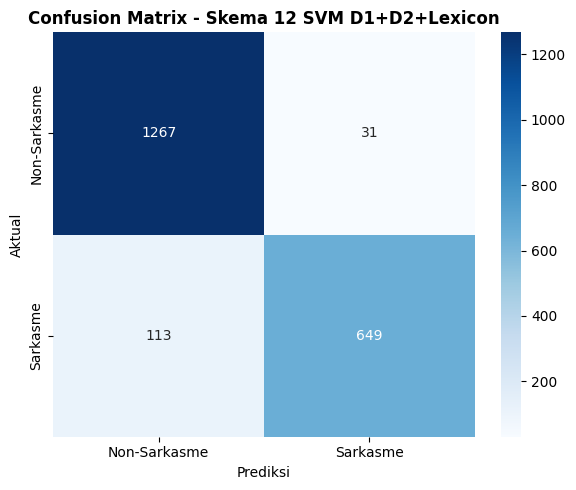

💾 Hasil sementara disimpan (12 skema selesai)


In [ ]:
nama = 'Skema 12 SVM D1+D2+Lexicon'
if nama in all_results:
    print(f"⏭️ {nama} sudah selesai, skip!")
else:
    print(f"🚀 {nama}")
    y_true_s12, y_pred_s12, y_prob_s12, hasil_s12 = train_svm_teks_balanced(
        df_train_d1d2, df_val_d1d2, df_test_d1d2,
        nama_skema=nama, lexicon_dict=lexicon_svm_dict
    )
    all_results[nama]    = hasil_s12
    all_preds_dict[nama] = (y_true_s12, y_pred_s12, y_prob_s12)
    simpan_sementara()

**21 - Rekap Hasil 12 Skema**


  REKAP HASIL 12 SKEMA
                                 Skema  Accuracy  F1-Score  Precision   Recall
   Skema 1 IndoBERT D1 - Tanpa Lexicon  0.954253  0.954172   0.954447 0.954253
        Skema 2 SVM D1 - Tanpa Lexicon  0.949098  0.948756   0.951869 0.949098
   Skema 3 IndoBERT D2 - Tanpa Lexicon  0.891732  0.894734   0.898912 0.891732
        Skema 4 SVM D2 - Tanpa Lexicon  0.905512  0.905512   0.905512 0.905512
Skema 5 IndoBERT D1+D2 - Tanpa Lexicon  0.932524  0.932478   0.932444 0.932524
     Skema 6 SVM D1+D2 - Tanpa Lexicon  0.928641  0.927948   0.929163 0.928641
           Skema 7 IndoBERT D1+Lexicon  0.953608  0.953513   0.953883 0.953608
                Skema 8 SVM D1+Lexicon  0.951031  0.950708   0.953741 0.951031
           Skema 9 IndoBERT D2+Lexicon  0.840551  0.831896   0.825732 0.840551
               Skema 10 SVM D2+Lexicon  0.889764  0.883370   0.880860 0.889764
       Skema 11 IndoBERT D1+D2+Lexicon  0.930097  0.930020   0.929973 0.930097
            Skema 12 SVM D1+

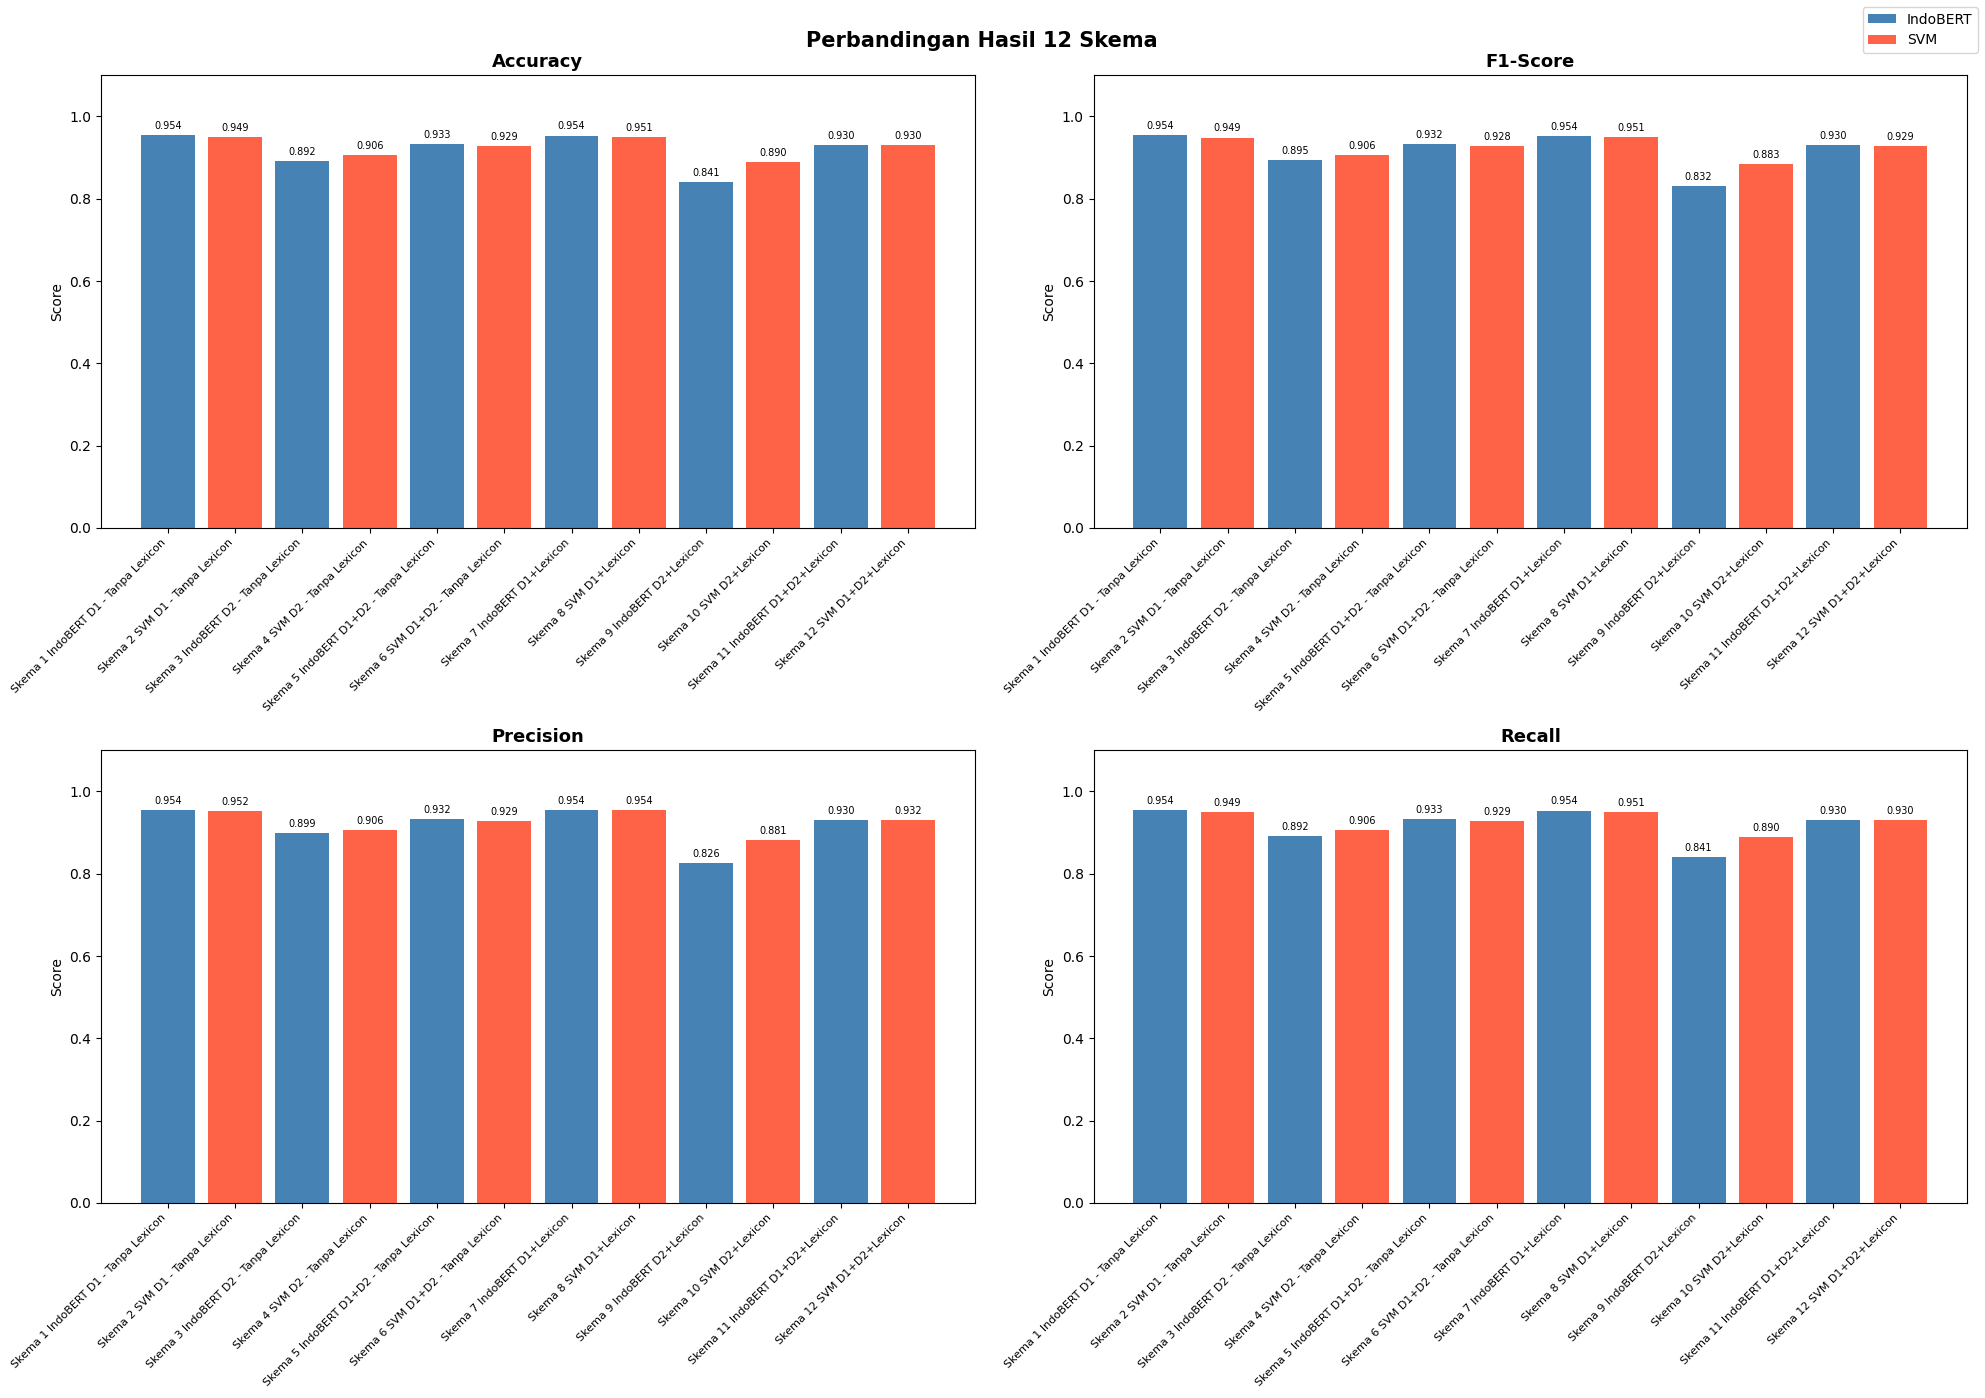

✅ Grafik perbandingan disimpan!


In [ ]:
df_hasil = pd.DataFrame([
    {
        'Skema'    : skema,
        'Accuracy' : v['accuracy'],
        'F1-Score' : v['f1'],
        'Precision': v['precision'],
        'Recall'   : v['recall']
    }
    for skema, v in all_results.items()
])

print("\n" + "="*70)
print("  REKAP HASIL 12 SKEMA")
print("="*70)
print(df_hasil.to_string(index=False))

df_hasil.to_csv(f"{save_path}/rekap_hasil_12skema.csv", index=False)
print(f"\n✅ Rekap hasil final disimpan!")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
colors  = ['steelblue' if 'IndoBERT' in s else 'tomato' for s in df_hasil['Skema']]

for ax, metric in zip(axes.flatten(), metrics):
    bars = ax.bar(range(len(df_hasil)), df_hasil[metric], color=colors)
    ax.set_xticks(range(len(df_hasil)))
    ax.set_xticklabels(df_hasil['Skema'], rotation=45, ha='right', fontsize=8)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, df_hasil[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

legend_elements = [
    Patch(facecolor='steelblue', label='IndoBERT'),
    Patch(facecolor='tomato',    label='SVM')
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)
plt.suptitle('Perbandingan Hasil 12 Skema', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{save_path}/grafik_perbandingan_12skema.png", dpi=300)
plt.show()
print("✅ Grafik perbandingan disimpan!")

**22 - ROC Curve per skema (12 subplot)**

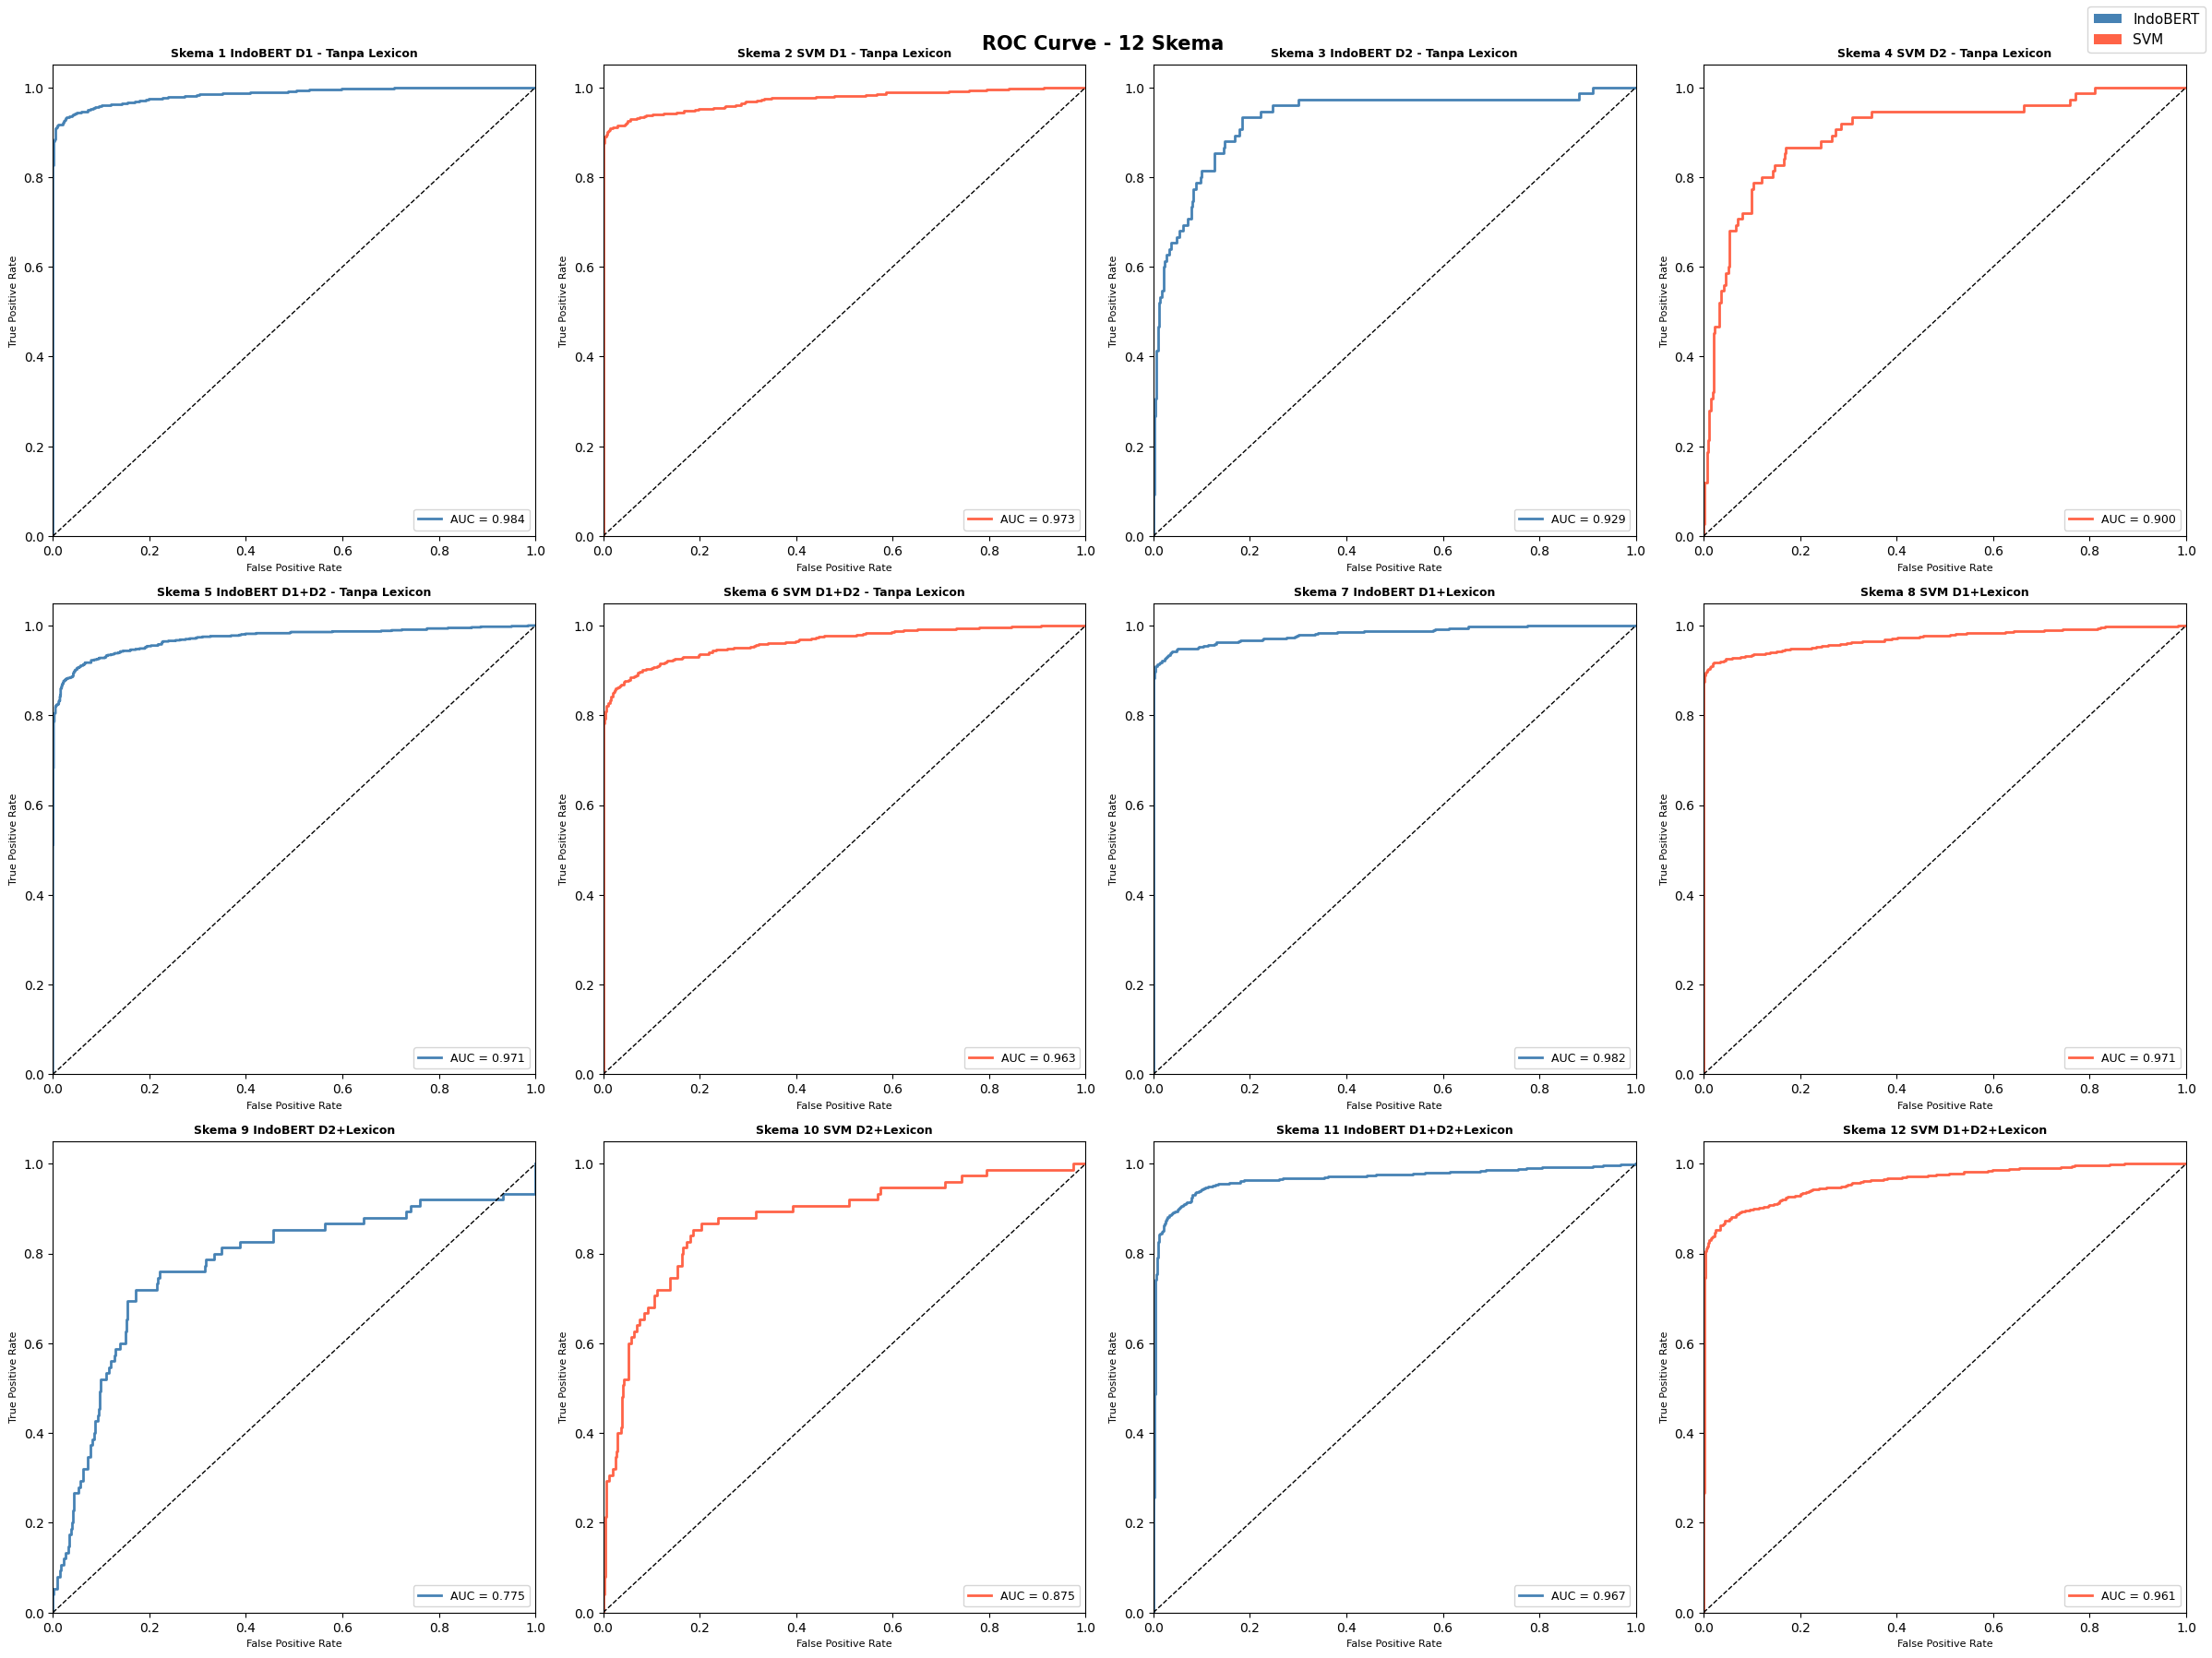

✅ ROC Curve disimpan!


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(24, 18))
axes = axes.flatten()

for idx, (nama, (y_true, y_pred, y_prob)) in enumerate(all_preds_dict.items()):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)
    color       = 'steelblue' if 'IndoBERT' in nama else 'tomato'

    axes[idx].plot(fpr, tpr, color=color, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[idx].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[idx].set_title(nama, fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('False Positive Rate', fontsize=8)
    axes[idx].set_ylabel('True Positive Rate', fontsize=8)
    axes[idx].legend(loc='lower right', fontsize=9)
    axes[idx].set_xlim([0, 1])
    axes[idx].set_ylim([0, 1.05])

legend_elements = [
    Patch(facecolor='steelblue', label='IndoBERT'),
    Patch(facecolor='tomato',    label='SVM')
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=11)
plt.suptitle('ROC Curve - 12 Skema', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{save_path}/roc_curve_12skema.png", dpi=300)
plt.show()
print("✅ ROC Curve disimpan!")

**23 - PR Curve per skema (12 subplot)**

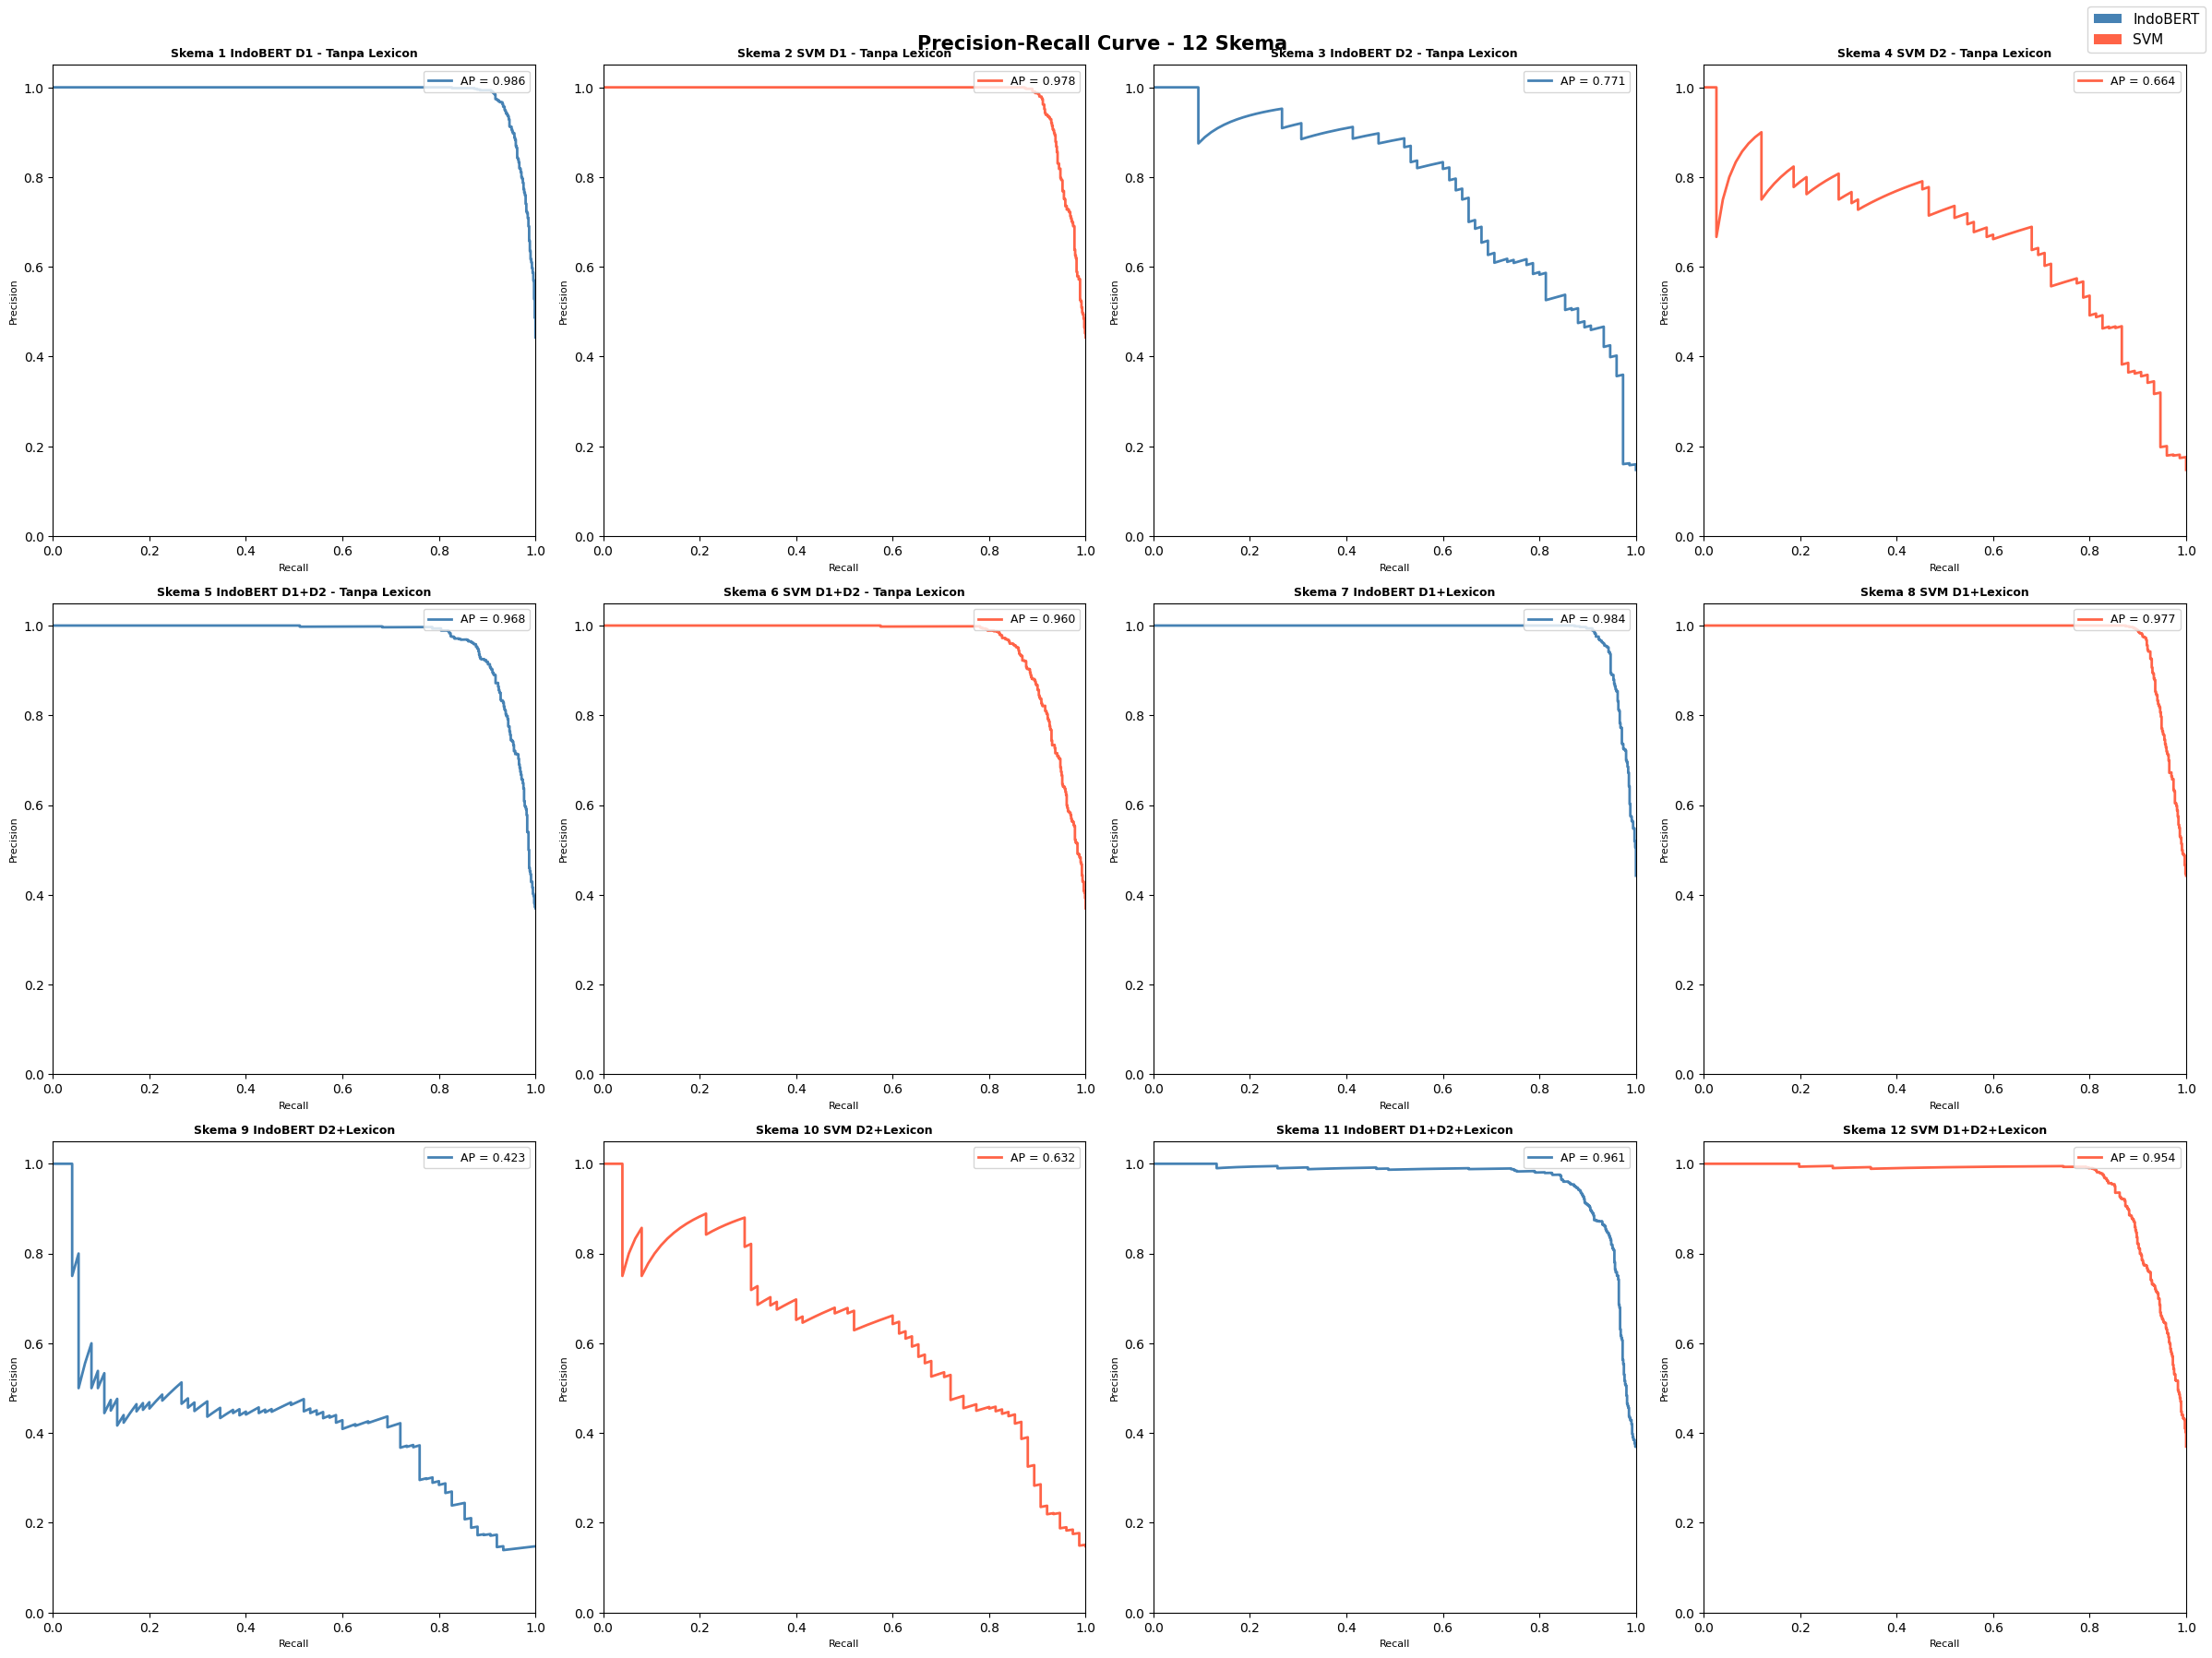

✅ PR Curve disimpan!


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(24, 18))
axes = axes.flatten()

for idx, (nama, (y_true, y_pred, y_prob)) in enumerate(all_preds_dict.items()):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap                   = average_precision_score(y_true, y_prob)
    color                = 'steelblue' if 'IndoBERT' in nama else 'tomato'

    axes[idx].plot(recall, precision, color=color, lw=2, label=f'AP = {ap:.3f}')
    axes[idx].set_title(nama, fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Recall', fontsize=8)
    axes[idx].set_ylabel('Precision', fontsize=8)
    axes[idx].legend(loc='upper right', fontsize=9)
    axes[idx].set_xlim([0, 1])
    axes[idx].set_ylim([0, 1.05])

legend_elements = [
    Patch(facecolor='steelblue', label='IndoBERT'),
    Patch(facecolor='tomato',    label='SVM')
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=11)
plt.suptitle('Precision-Recall Curve - 12 Skema', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{save_path}/pr_curve_12skema.png", dpi=300)
plt.show()
print("✅ PR Curve disimpan!")

**24 - Rekap AUC & AP**

In [ ]:
rekap_roc_pr = []
for nama, (y_true, y_pred, y_prob) in all_preds_dict.items():
    roc_auc = auc(*roc_curve(y_true, y_prob)[:2])
    ap      = average_precision_score(y_true, y_prob)
    rekap_roc_pr.append({
        'Skema' : nama,
        'AUC'   : round(roc_auc, 4),
        'AP'    : round(ap, 4)
    })

df_roc_pr = pd.DataFrame(rekap_roc_pr)
print("\n" + "="*55)
print("  REKAP AUC & AVERAGE PRECISION")
print("="*55)
print(df_roc_pr.to_string(index=False))

df_roc_pr.to_csv(f"{save_path}/rekap_auc_ap_12skema.csv", index=False)
print(f"\n✅ Rekap AUC & AP disimpan!")


  REKAP AUC & AVERAGE PRECISION
                                 Skema    AUC     AP
   Skema 1 IndoBERT D1 - Tanpa Lexicon 0.9844 0.9858
        Skema 2 SVM D1 - Tanpa Lexicon 0.9732 0.9779
   Skema 3 IndoBERT D2 - Tanpa Lexicon 0.9294 0.7713
        Skema 4 SVM D2 - Tanpa Lexicon 0.9003 0.6643
Skema 5 IndoBERT D1+D2 - Tanpa Lexicon 0.9710 0.9680
     Skema 6 SVM D1+D2 - Tanpa Lexicon 0.9631 0.9598
           Skema 7 IndoBERT D1+Lexicon 0.9820 0.9844
                Skema 8 SVM D1+Lexicon 0.9710 0.9767
           Skema 9 IndoBERT D2+Lexicon 0.7754 0.4234
               Skema 10 SVM D2+Lexicon 0.8748 0.6317
       Skema 11 IndoBERT D1+D2+Lexicon 0.9668 0.9614
            Skema 12 SVM D1+D2+Lexicon 0.9606 0.9540

✅ Rekap AUC & AP disimpan!


**25 - ROC Curve gabungan 12 skema**

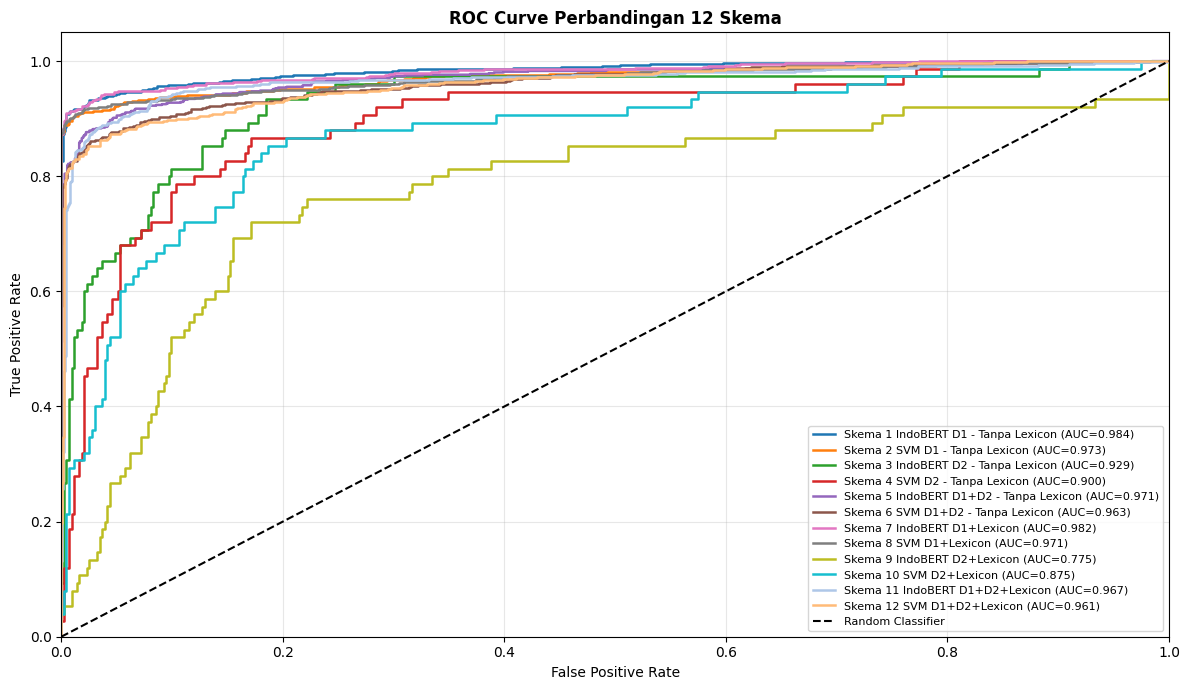

✅ ROC gabungan disimpan!


In [ ]:
from sklearn.metrics import roc_curve, auc

warna = [
    '#1f77b4','#ff7f0e','#2ca02c','#d62728',
    '#9467bd','#8c564b','#e377c2','#7f7f7f',
    '#bcbd22','#17becf','#aec7e8','#ffbb78'
]

fig, ax = plt.subplots(figsize=(12,7))

for (nama, (y_true, _, y_prob)), color in zip(all_preds_dict.items(), warna):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr,
        tpr,
        lw=1.8,
        color=color,
        label=f"{nama} (AUC={roc_auc:.3f})"
    )

ax.plot([0,1],[0,1],'k--',label='Random Classifier')

ax.set_xlim(0,1)
ax.set_ylim(0,1.05)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Perbandingan 12 Skema", fontweight='bold')

ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{save_path}/roc_curve_perbandingan_12skema.png", dpi=300)
plt.show()

print("✅ ROC gabungan disimpan!")

**26 - PR Curve gabungan 12 skema**

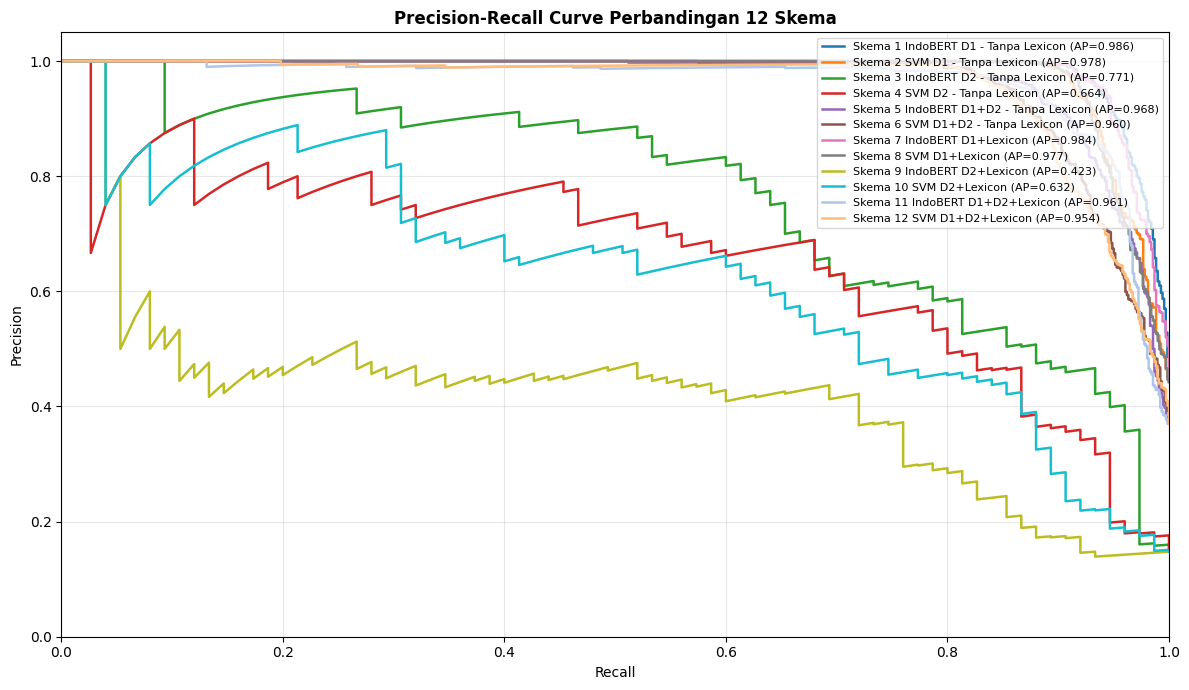

✅ PR gabungan disimpan!


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

warna = [
    '#1f77b4','#ff7f0e','#2ca02c','#d62728',
    '#9467bd','#8c564b','#e377c2','#7f7f7f',
    '#bcbd22','#17becf','#aec7e8','#ffbb78'
]

fig, ax = plt.subplots(figsize=(12,7))

for (nama, (y_true, _, y_prob)), color in zip(all_preds_dict.items(), warna):

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    ax.plot(
        recall,
        precision,
        lw=1.8,
        color=color,
        label=f"{nama} (AP={ap:.3f})"
    )

ax.set_xlim(0,1)
ax.set_ylim(0,1.05)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve Perbandingan 12 Skema", fontweight='bold')

ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{save_path}/pr_curve_perbandingan_12skema.png", dpi=300)
plt.show()

print("✅ PR gabungan disimpan!")